In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

1. Загрузите встроенные данные sklearn.datasets.load_iris, взяв только последние два столбца (длина и ширина лепестков). Изобразите их на диаграмме рассеяния, подкрасив каждый класс некоторым цветом.

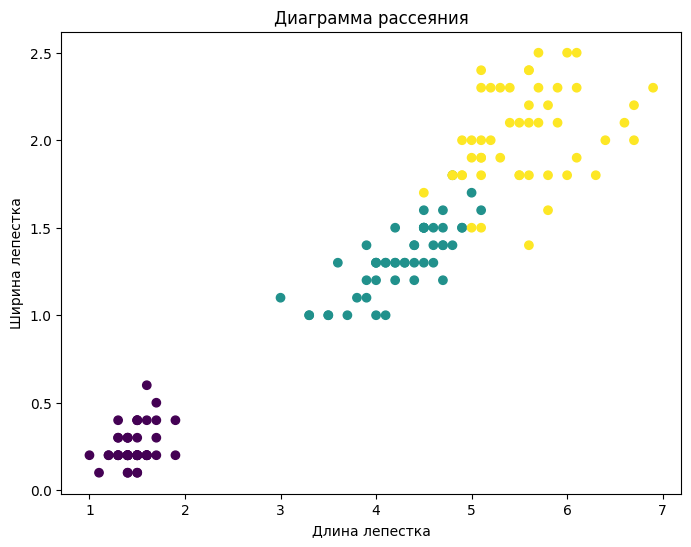

In [ ]:
iris = load_iris()
X_iris = iris.data[:, 2:]
y_iris = iris.target

plt.figure(figsize=(8, 6))
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap='viridis')
plt.xlabel('Длина лепестка')
plt.ylabel('Ширина лепестка')
plt.title('Диаграмма рассеяния')
plt.show()

2. Обучите модель классификационного дерева принятия решений sklearn.tree.DecisionTreeClassifier глубины 4, используя энтропию. Визуализируйте соответствующий граф дерева принятия решений.

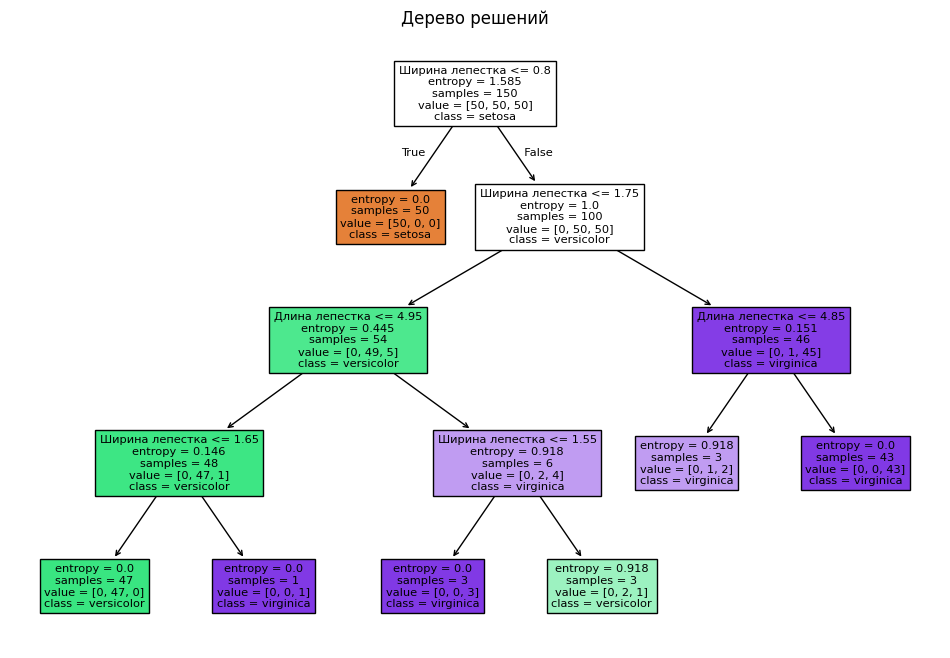

In [ ]:
clf_iris = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf_iris.fit(X_iris, y_iris)

plt.figure(figsize=(12, 8))
plot_tree(clf_iris, filled=True, feature_names=['Длина лепестка', 'Ширина лепестка'],
          class_names=iris.target_names)
plt.title('Дерево решений')
plt.show()

3. Обучите модель классификационного дерева принятия решений sklearn.tree.DecisionTreeClassifier с разными глубинами (1, 2, 3, 4, 10), используя энтропию, и визуализируйте в каждом случае полученные разделяющие области.

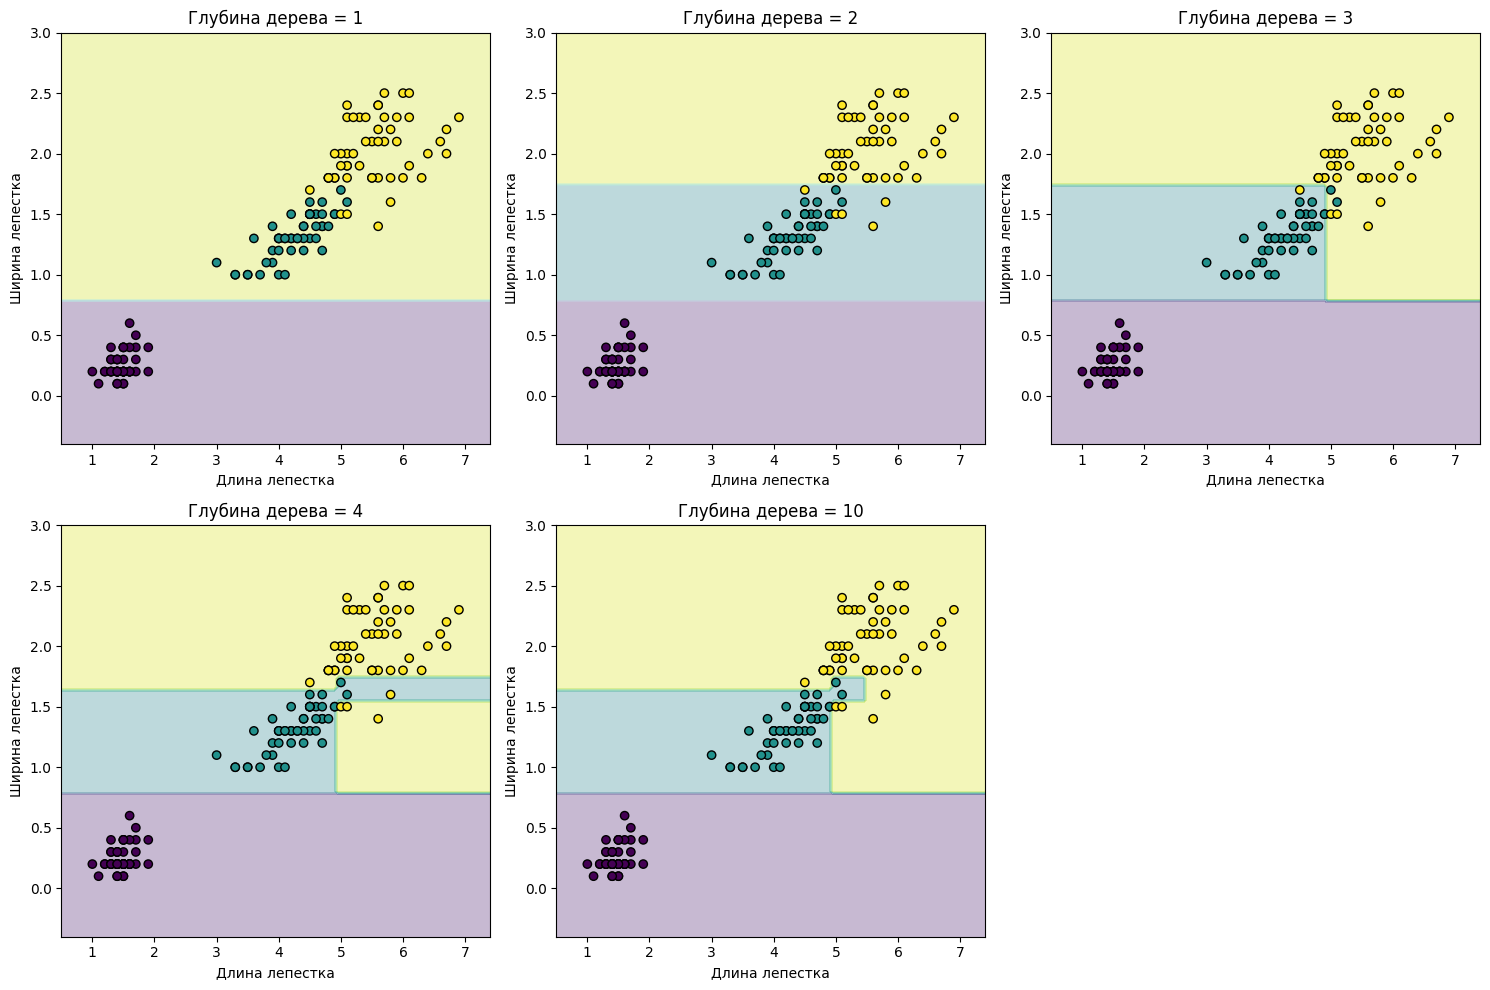

In [ ]:
depths = [1, 2, 3, 4, 10]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, depth in enumerate(depths):
    clf_temp = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=0)
    clf_temp.fit(X_iris, y_iris)

    x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
    y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = clf_temp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    axes[i].scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap='viridis', edgecolors='k')
    axes[i].set_xlabel('Длина лепестка')
    axes[i].set_ylabel('Ширина лепестка')
    axes[i].set_title(f'Глубина дерева = {depth}')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

4. Выведите необходимые метрики для оценки работы моделей с разными глубинами. Сделайте вывод о том, какая модель лучше классифицирует данные.

In [ ]:
for depth in depths:
    clf_temp = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=0)
    clf_temp.fit(X_iris, y_iris)
    y_pred = clf_temp.predict(X_iris)
    accuracy = accuracy_score(y_iris, y_pred)
    f1 = f1_score(y_iris, y_pred, average='weighted')

    print(f"Глубина {depth}: Accuracy = {accuracy:.4f}, F1-score = {f1:.4f}")

Глубина 1: Accuracy = 0.6667, F1-score = 0.5556
Глубина 2: Accuracy = 0.9600, F1-score = 0.9599
Глубина 3: Accuracy = 0.9733, F1-score = 0.9733
Глубина 4: Accuracy = 0.9867, F1-score = 0.9867
Глубина 10: Accuracy = 0.9933, F1-score = 0.9933


5. Загрузите весь датасет load_iris. Обучите модель классификационного дерева принятия решений sklearn.tree.DecisionTreeClassifier глубины 4, используя энтропию. Визуализируйте соответствующий граф дерева решений. Оцените качество работы модели.

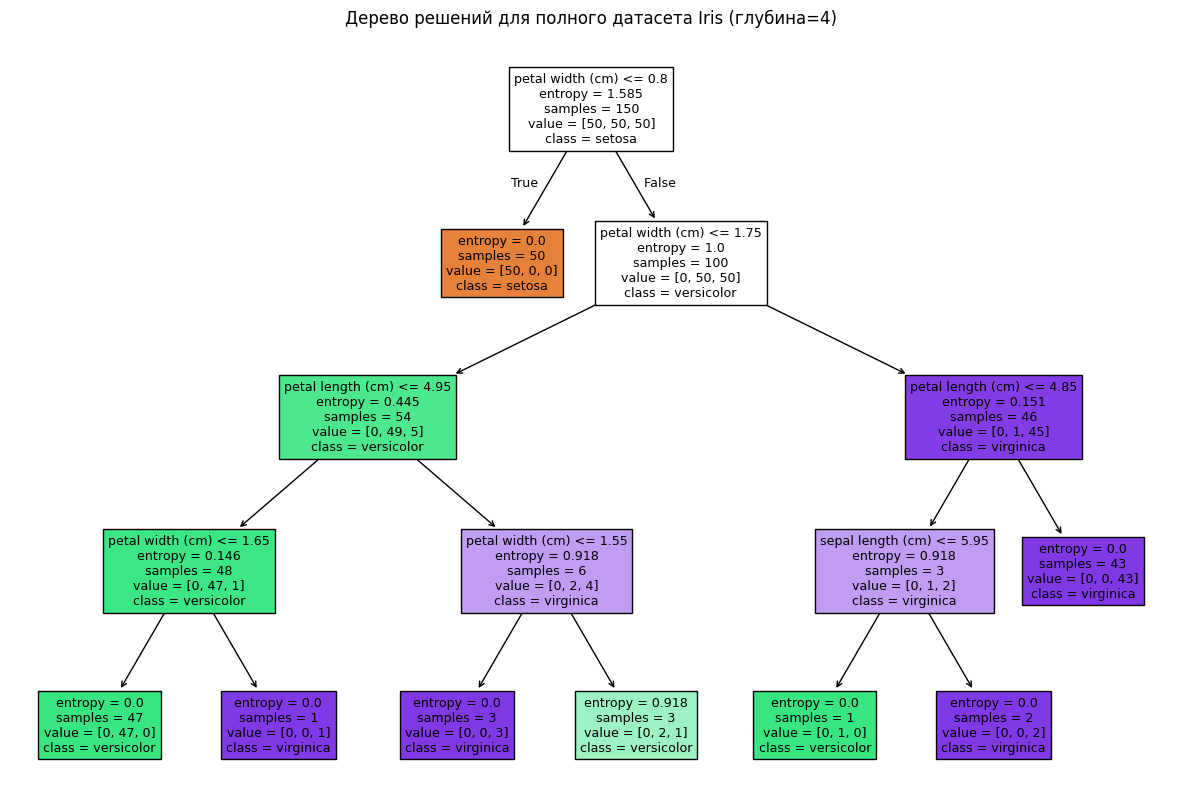


Качество модели на полном датасете Iris:
Accuracy = 0.9933
F1-score = 0.9933
Матрица ошибок:
[[50  0  0]
 [ 0 50  0]
 [ 0  1 49]]


In [ ]:
X_iris_full = iris.data
y_iris_full = iris.target

clf_iris_full = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf_iris_full.fit(X_iris_full, y_iris_full)

plt.figure(figsize=(15, 10))
plot_tree(clf_iris_full, filled=True, feature_names=iris.feature_names,
          class_names=iris.target_names)
plt.title('Дерево решений для полного датасета Iris (глубина=4)')
plt.show()

y_pred_full = clf_iris_full.predict(X_iris_full)
accuracy_full = accuracy_score(y_iris_full, y_pred_full)
f1_full = f1_score(y_iris_full, y_pred_full, average='weighted')

print(f"\nКачество модели на полном датасете Iris:")
print(f"Accuracy = {accuracy_full:.4f}")
print(f"F1-score = {f1_full:.4f}")
print("Матрица ошибок:")
print(confusion_matrix(y_iris_full, y_pred_full))

6. Загрузите встроенные данные sklearn.datasets.california_housing, взяв только столбец AveBedrms в качестве единственного признака. Изобразите данные на диаграмме рассеяния так, чтобы на одной оси были отмечены значения признака, а на другой - целевой переменной.

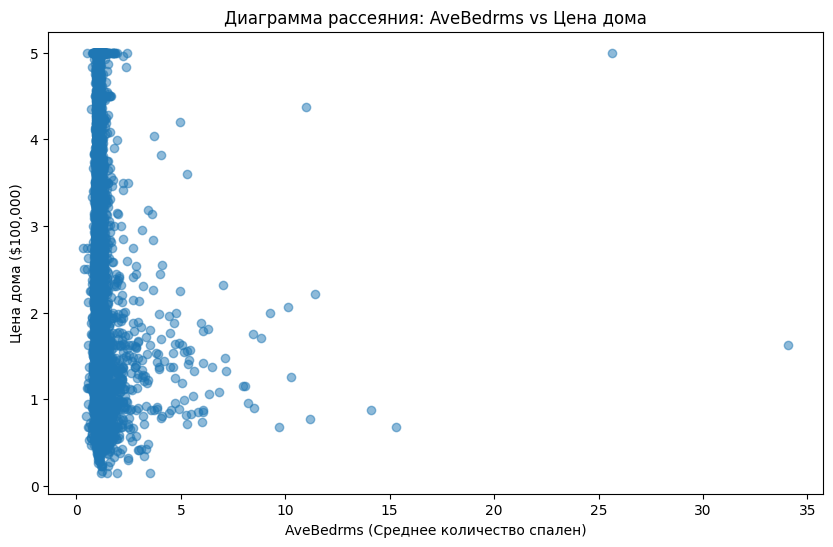

In [ ]:
california = fetch_california_housing()
X_california_single = california.data[:, [3]]
y_california_single = california.target

plt.figure(figsize=(10, 6))
plt.scatter(X_california_single, y_california_single, alpha=0.5)
plt.xlabel('AveBedrms (Среднее количество спален)')
plt.ylabel('Цена дома ($100,000)')
plt.title('Диаграмма рассеяния: AveBedrms vs Цена дома')
plt.show()

7. Обучите модель регрессионного дерева принятия решений sklearn.tree.DecisionTreeRegressor, зафиксировав random_state=0, а остальными гиперпараметрами по умолчению.

In [ ]:
reg_california_single = DecisionTreeRegressor(random_state=0)
reg_california_single.fit(X_california_single, y_california_single)

DecisionTreeRegressor(random_state=0)

8. Визуализируйте соответствующий граф дерева решений и получившуюся кусочную линию регрессии.

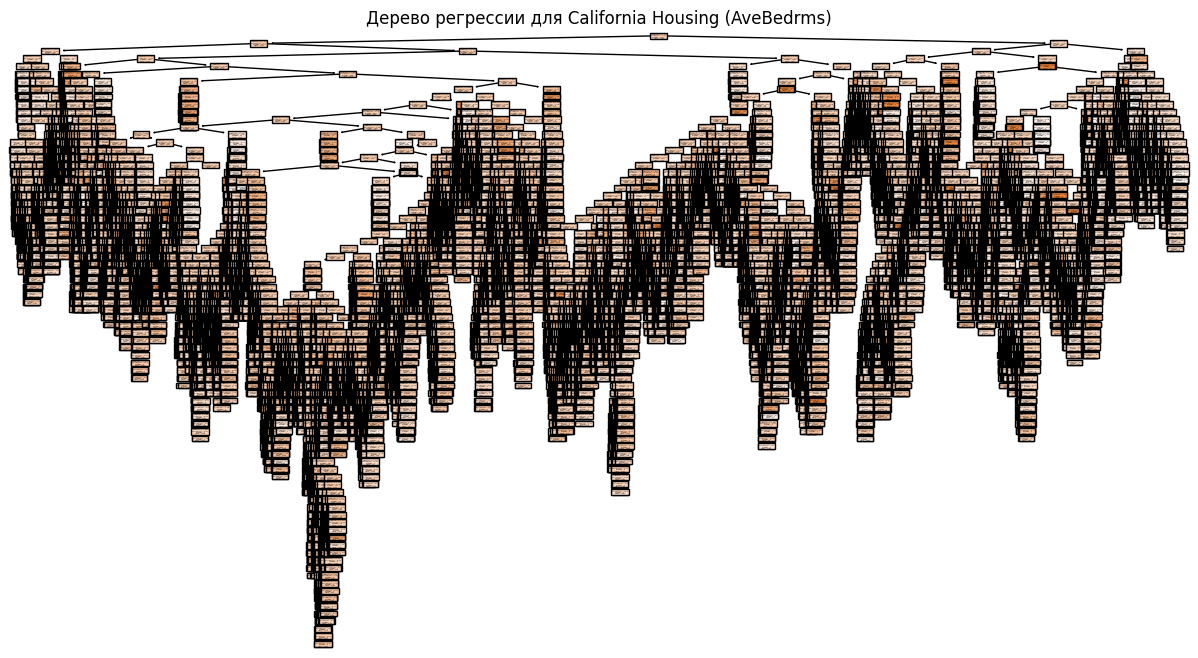

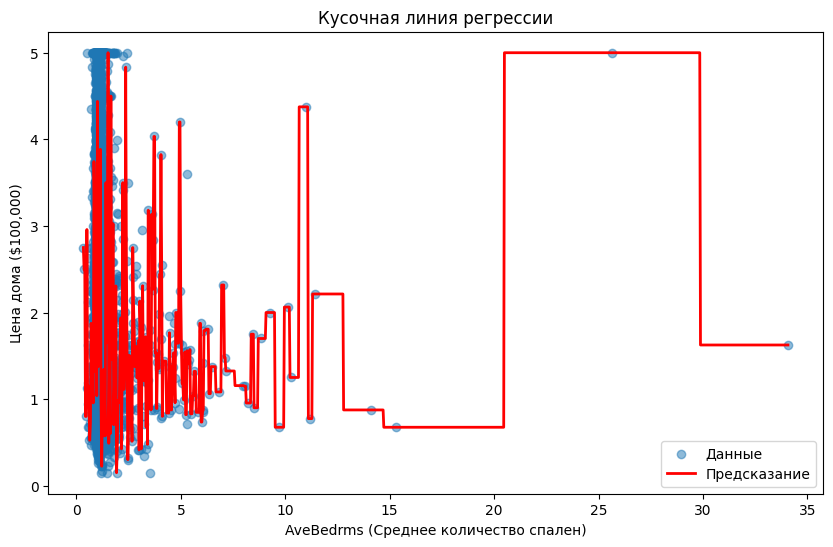

In [ ]:
plt.figure(figsize=(15, 8))
plot_tree(reg_california_single,
          filled=True,
          feature_names=['AveBedrms'],
          max_depth=3,
          fontsize=10)
plt.title('Дерево регрессии для California Housing (первые 3 уровня)')
plt.show()

X_test_single = np.linspace(X_california_single.min(), X_california_single.max(), 1000).reshape(-1, 1)
y_pred_single = reg_california_single.predict(X_test_single)

plt.figure(figsize=(10, 6))
plt.scatter(X_california_single, y_california_single, alpha=0.5, label='Данные', s=10)
plt.plot(X_test_single, y_pred_single, 'r-', linewidth=2, label='Предсказание')
plt.xlabel('AveBedrms (Среднее количество спален)')
plt.ylabel('Цена дома ($100,000)')
plt.title('Кусочная линия регрессии')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


9. Оцените качество работы модели. Создайте новое наблюдение и сделайте предсказание на нём.

In [ ]:
y_pred_california_single = reg_california_single.predict(X_california_single)
r2_single = r2_score(y_california_single, y_pred_california_single)
mse_single = mean_squared_error(y_california_single, y_pred_california_single)

print(f"\nКачество регрессионной модели (только AveBedrms):")
print(f"R² = {r2_single:.4f}")
print(f"MSE = {mse_single:.4f}")

new_observation = [[1.5]]
prediction = reg_california_single.predict(new_observation)
print(f"\nПредсказание для нового наблюдения (AveBedrms = 1.5): {prediction[0]:.4f}")


Качество регрессионной модели (только AveBedrms):
R² = 0.6792
MSE = 0.4272

Предсказание для нового наблюдения (AveBedrms = 1.5): 2.5626


10. Загрузите весь датасет fetch_california_housing. Обучите ту же модель. Визуализируйте соответствующий граф дерева решений и оцените качество работы модели.

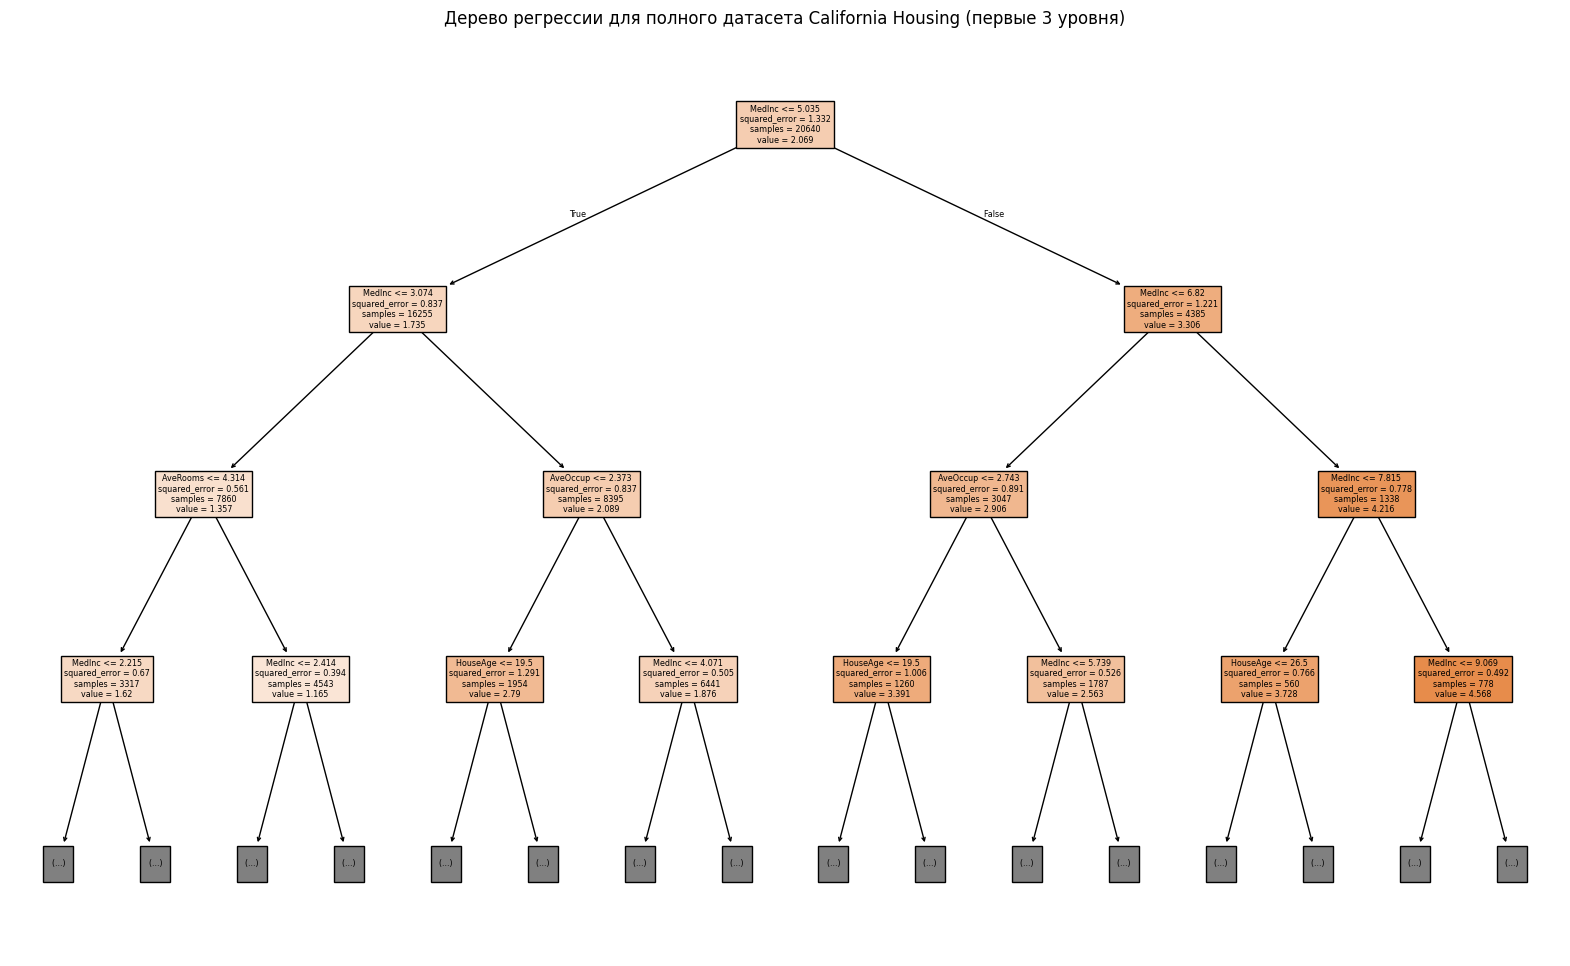


Качество регрессионной модели на полном датасете California Housing:
R² = 1.0000
MSE = 0.0000


In [ ]:
X_california_full = california.data
y_california_full = california.target

reg_california_full = DecisionTreeRegressor(random_state=0)
reg_california_full.fit(X_california_full, y_california_full)

plt.figure(figsize=(20, 12))
plot_tree(reg_california_full, filled=True, feature_names=california.feature_names, max_depth=3)
plt.title('Дерево регрессии для полного датасета California Housing (первые 3 уровня)')
plt.show()

y_pred_california_full = reg_california_full.predict(X_california_full)
r2_full = r2_score(y_california_full, y_pred_california_full)
mse_full = mean_squared_error(y_california_full, y_pred_california_full)

print(f"\nКачество регрессионной модели на полном датасете California Housing:")
print(f"R² = {r2_full:.4f}")
print(f"MSE = {mse_full:.4f}")